### This notebook is a test of "of_bpdrr.py" as a module that contains the functions of all 6 objective functions of the Battle of Postdisaster Response and Restoration

In [127]:
# Import libraries to be used, including "OF_BPDRR", which contains the objective fuctions of the BPDRR
import OF_BPDRR as OF
import wntr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [128]:
# Import the water network model
ds_sel = 'DS5' # which damage scenario to analyse
#inp_file = "BBM-EPS_"+ds_sel+"mcg.inp"
inp_file = "BBM-EPS_"+ds_sel+"_restoration_1RC_max.inp"
wn = wntr.network.WaterNetworkModel(inp_file)

In [129]:
# Simulation settings
wn.options.time.duration = 7 * 24 * 3600       # 7 days
wn.options.time.hydraulic_timestep = 15*60     # 15 minutes
wn.options.time.report_timestep = 15*60        # 15 minutes

# Start simulation at 07:00 AM
wn.options.time.start_clocktime = 7 * 3600

# Pressure Driven Analysis
wn.options.hydraulic.demand_model = "PDA"
wn.options.hydraulic.required_pressure = 20
wn.options.hydraulic.minimum_pressure = 0
wn.options.hydraulic.pressure_exponent = 0.5

In [130]:
# timestep
dt = wn.options.time.hydraulic_timestep

# timestep in minutes
dtm = dt/60

In [131]:
# run the simulation
sim = wntr.sim.EpanetSimulator(wn)
results = sim.run_sim()

In [132]:
# getting the actual demand at each node over time 
demand = results.node["demand"]*1000  # convert to L/s

In [133]:
# Find all demand nodes (base demand > 0)
demand_nodes = []

for node_name in wn.junction_name_list:

    node = wn.get_node(node_name)

    if node.base_demand > 0:

        demand_nodes.append(node_name)

print(f"Demand nodes found: {len(demand_nodes)}")

Demand nodes found: 4201


In [134]:
# Expected demand
expected = wntr.metrics.expected_demand(wn)

expected *= 1000        # convert to L/s

expected = expected[demand_nodes]

expected.index = demand.index

In [135]:
# Calculate the supply ratio at each time step
supply_ratio = demand[demand_nodes] / expected

# Clip the supply ratio to be between 0 and 1
supply_ratio = supply_ratio.clip(lower=0, upper=1)

In [136]:
# Finding emitter nodes (nodes starting with "E_")
emitter_nodes = [
    j for j in wn.junction_name_list
    if j.startswith("E_")
]

# Demand at emitter nodes (leakage) over time
leakage = demand[emitter_nodes]

### Functionality 
The percentage of the demand supplied by the distribution system.

In [137]:
functionality_series = OF.system_functionality(demand, demand_nodes, expected)

print(functionality_series)

0         100.000000
900       100.000000
1800      100.000000
2700       97.684080
3600       97.876048
             ...    
601200    100.000000
602100    100.000000
603000    100.000000
603900    100.000000
604800    100.000000
Length: 673, dtype: float64


### 1. OF: Time without supply for hospital/firefighting (FH)
The time that the hospitals and the firefighting flows are without supply It's calculated by multiplying the simulation time step duration  with the number of time steps in which the supply/demand ratio for the hospitals and firefighting flows was less than 0.5.

In [138]:
FH_value, FH_undersupplied = OF.OF_FH(supply_ratio, dtm)

print(f"FH = {FH_value:,.2f} minutes") 

FH = 0.00 minutes


### 2. rapidity of recovery (t95)
The time that the hospitals and the firefighting flows are without supply It's calculated by multiplying the simulation time step duration  with the number of time steps in which the supply/demand ratio for the hospitals and firefighting flows was less than 0.5.

In [139]:
t95 = OF.OF_t95(demand, demand_nodes, expected, dtm)

print(f"Rapidity of recovery (t95): {t95:.2f}")

Rapidity of recovery (t95): 0.00


### 3. OF: Resilience loss (RL)
RL considers the Accumulated loss of functionality during the recovery process of the system. It represents the area between the full functionality line (100%) and the functionality time series

In [140]:
RL = OF.OF_RL(demand, demand_nodes, expected, dtm)

print(f"Resilience Loss = {RL:,.2f} %-minutes")

Resilience Loss = 593.21 %-minutes


### 4. OF: Average time of no user service (Time no serv.)
Measures the average time each demand node across the network stayed without service. The formula of this objective is similar to the FH formula, but it considers the sum of all demand nodes that were undersupplied (supply/demand ratio under 0.5) divided by the total amount of demand nodes (DN)

In [141]:
time_no_serv = OF.OF_time_no_serv(supply_ratio, dtm)

print(f"Average Time of No User Service = {time_no_serv:.2f} minutes")

Average Time of No User Service = 9.40 minutes


### 5. OF: Number of users without service for eight consecutive hours (NWSECH)
Number of demand nodes that stayed without service for more than eight consecutive hours. It’s calculated by counting the amount of nodes with at least one continuous 8-hour period during which the node's supply/demand ratio never exceeds 0.5.

In [142]:
NNS = OF.OF_NWSECH(supply_ratio, dtm)

print(f"Nodes without service for 8 consecutive hours = {NNS}")

Nodes without service for 8 consecutive hours = 0


### 6. OF: Water loss (WL)
counts the volume in litres of water lost during the period after the earthquake, by multiplying the time step with the sum of the outflows across all damages in the system.

In [143]:
WL = OF.OF_WL(demand, emitter_nodes, dt)

print(f"Water loss = {WL:,.2f} m³")

Water loss = 1,061.49 m³


### Ploting water loss and resilience loss + recovery time

In [144]:
functionality_series = OF.system_functionality(demand, demand_nodes, expected)

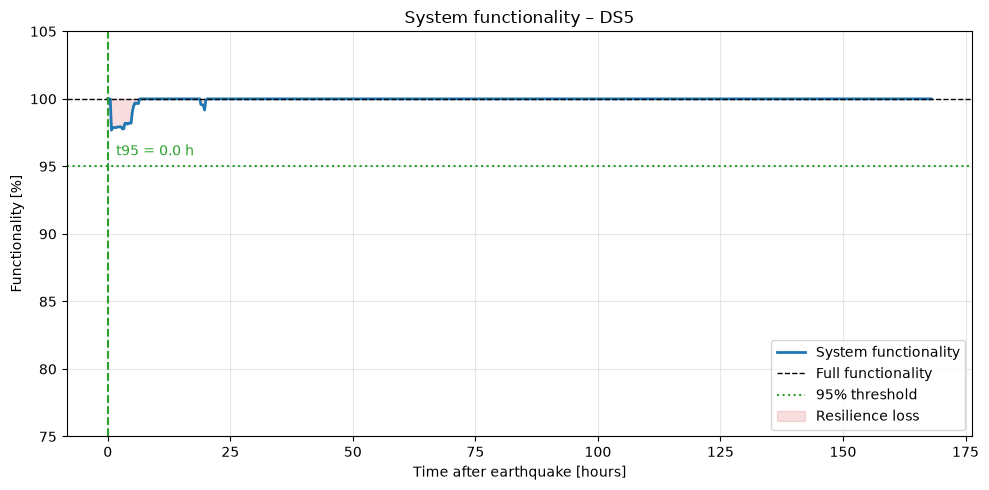

In [145]:
# Plot functionality over the simulation period
time_hours = functionality_series.index.to_numpy() / 3600

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(time_hours, functionality_series.to_numpy(), color="tab:blue", linewidth=2,
        label="System functionality")
ax.axhline(100, color="black", linestyle="--", linewidth=1, label="Full functionality")
ax.axhline(95, color="tab:green", linestyle=":", linewidth=1.5, label="95% threshold")

# Shade the resilience loss: the area between actual and full functionality.
ax.fill_between(time_hours, functionality_series.to_numpy(), 100,
                color="tab:red", alpha=0.15, label="Resilience loss")

# t95 is stored in seconds; show it only if 95% functionality is reached permanently.
if np.isfinite(t95):
    t95_hours = t95 / 60
    ax.axvline(t95_hours, color="tab:green", linestyle="--", linewidth=1.5)
    ax.annotate(f"t95 = {t95_hours:.1f} h", xy=(t95_hours, 95),
                xytext=(6, 8), textcoords="offset points", color="tab:green")

ax.set(title=f"System functionality – {ds_sel}", xlabel="Time after earthquake [hours]",
       ylabel="Functionality [%]", ylim=(75, 105))
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()
plt.show()

# Optional: save a publication-quality copy.
# fig.savefig(f"functionality_{ds_sel}.png", dpi=300, bbox_inches="tight")

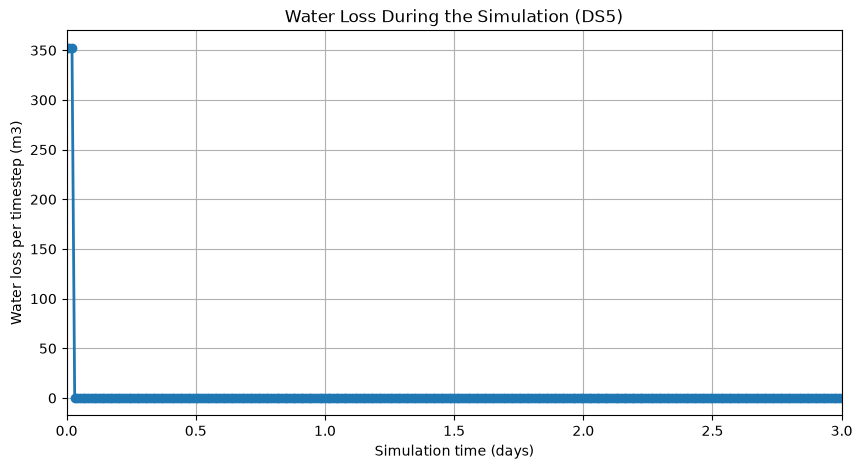

In [146]:
# total leakage flow at each timestep
leakage_flow_ts = leakage.sum(axis=1)

# Water loss during each timestep
water_loss_ts = (leakage_flow_ts * dt)/1000

# Accumulated water loss (L)
cumulative_loss = water_loss_ts.cumsum()

plt.figure(figsize=(10,5))

# Convert seconds to days
time_days = water_loss_ts.index / (24 * 3600)

plt.plot(
    time_days,
    water_loss_ts,
    marker='o',
    linewidth=2
)

plt.xlabel("Simulation time (days)")
plt.ylabel("Water loss per timestep (m3)")
plt.title(f"Water Loss During the Simulation ({ds_sel})")
plt.grid(True)

plt.xlim(0, 3)

plt.show()

In [147]:
# Values of all objective functions
print(f"FH = {FH_value:,.2f} minutes")
print(f"Rapidity of recovery (t95): {t95:.2f}")
print(f"Resilience Loss = {RL:,.2f} %-minutes")
print(f"Average Time of No User Service = {time_no_serv:.2f} minutes")
print(f"Nodes without service for 8 consecutive hours = {NNS}")
print(f"Water loss = {WL:,.2f} m³") 

FH = 0.00 minutes
Rapidity of recovery (t95): 0.00
Resilience Loss = 593.21 %-minutes
Average Time of No User Service = 9.40 minutes
Nodes without service for 8 consecutive hours = 0
Water loss = 1,061.49 m³
